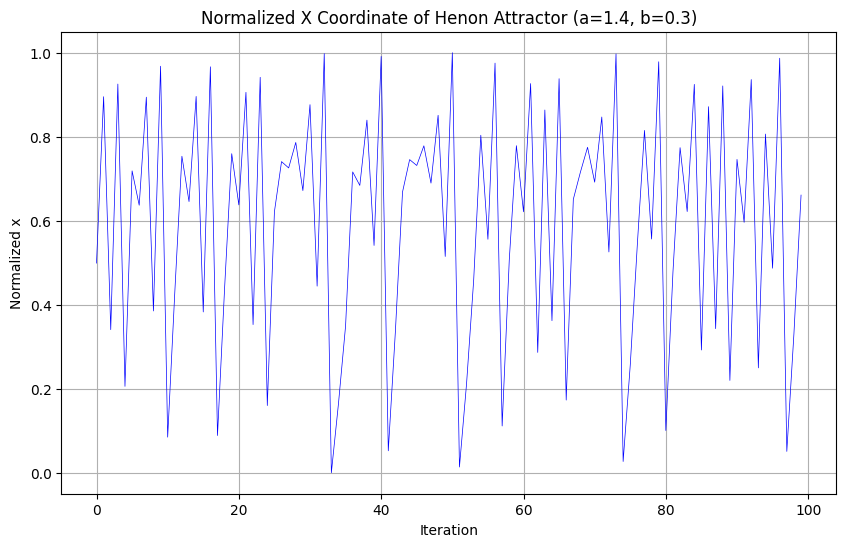

In [8]:
import matplotlib.pyplot as plt
import numpy as np

class Henon:
    def __init__(self, a=1.4, b=0.3):
        self.a = a
        self.b = b

    def generate(self, steps, x0=0.0, y0=0.0):
        x = np.zeros(steps)
        y = np.zeros(steps)
        x[0], y[0] = x0, y0
        for i in range(1, steps):
            x[i] = 1 - self.a * x[i-1]**2 + y[i-1]
            y[i] = self.b * x[i-1]
        return x, y

class TimeSeries:
    def __init__(self, series_type="Lorentz", size=0, r=28, dt=0.01, array=None, a=1.4, b=0.3):
        if series_type == "Lorentz":
            divisor = int(0.1 / dt)
            x, _, _ = Lorentz().generate(dt=dt, steps=size * divisor, r=r)
            x = (x - x.min()) / (x.max() - x.min())
            self.values = x[::divisor]
        elif series_type == "Henon":
            x, _ = Henon(a=a, b=b).generate(steps=size)
            x = (x - x.min()) / (x.max() - x.min())
            self.values = x
        else:
            self.values = np.array(array)
            self.values = (self.values - self.values.min()) / (self.values.max() - x.min())
        self.train = None
        self.test = None

    def split_train_val_test(self, window_index, test_size):
        if window_index + test_size > len(self.values):
            raise ValueError("test index out of range")
        self.train = self.values[:window_index]
        self.test = self.values[window_index:window_index + test_size]

# Параметры
size = 100  # Количество точек
a = 1.4
b = 0.3

# Создание временного ряда для аттрактора Хенона
ts = TimeSeries(series_type="Henon", size=size, a=a, b=b)

# Построение графика нормированной координаты x
plt.figure(figsize=(10, 6))
plt.plot(range(size), ts.values, '-', color='blue', linewidth=0.5)
plt.title("Normalized X Coordinate of Henon Attractor (a=1.4, b=0.3)")
plt.xlabel("Iteration")
plt.ylabel("Normalized x")
plt.grid(True)
plt.show()